La tabla contiene los datos de ventas de los productos de Serenatto en el último semestre de 2023 de esta sucursal y se puede acceder en el archivo panini.csv. Para analizar los datos, Daniela creó el siguiente prompt para generar una visualización de las ventas de este producto con el soporte de ChatGPT:

"""Tenemos un DataFrame llamado "df" y queremos construir un gráfico de línea que muestre las ventas de "Panini" por mes. Utiliza solo las columnas de "df":

fecha: con la fecha de las ventas ya en formato datetime (aaaa-mm-dd)

valor: con el valor de cada venta.

producto: con los productos vendidos. Vamos a utilizar el producto "Panini".

Agrupa las fechas de la columna "fecha" por mes y agrega los datos solo por la suma de las ventas. Por último, cambia el eje de las fechas para mostrar los meses escritos.

Utiliza las bibliotecas de visualización de datos de Python para crear esta visualización."""

Considerando este prompt escrito para ChatGPT, ¿cuál de los códigos a continuación es una posible respuesta de ChatGPT?

---
---

In [4]:

import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [5]:
url_panini = "https://gist.githubusercontent.com/ahcamachod/c1cef14e116881abab3239822ebe610a/raw/1ba8ff2bb1d5849e5451be125295167dcc3563eb/panini.csv"

In [13]:
df = pd.read_csv(url_panini)

In [14]:
df

,id,fecha,producto,valor,metodo_pago
0,2720,2023-07-01,Risoto de Funghi,13.0,Tarjeta de Débito
1,2721,2023-07-02,Tiramisú,10.0,Tarjeta de Débito
2,2722,2023-07-02,Tiramisú,10.0,Tarjeta de Crédito
3,2723,2023-07-02,Ratatouille,8.5,Transferencia
4,2724,2023-07-03,Ratatouille,8.5,Efectivo
...,...,...,...,...,...
851,3571,2023-12-31,Panini,7.5,Transferencia
852,3572,2023-12-31,Pizza Margherita,12.0,Efectivo
853,3573,2023-12-31,Bruschetta,7.0,Efectivo
854,3574,2023-12-31,Gnocchi,10.5,Tarjeta de Débito


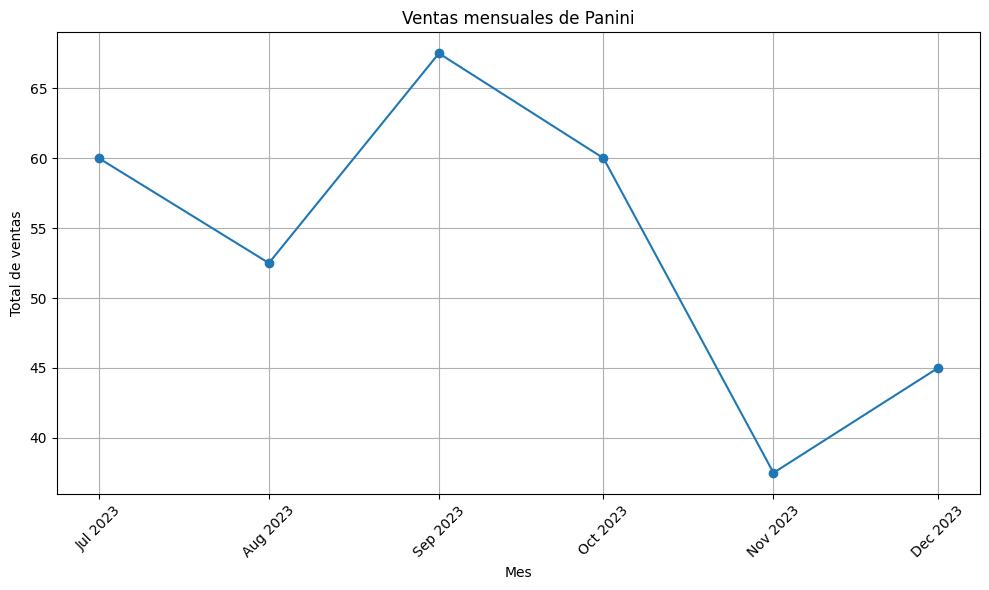

In [17]:
import matplotlib.pyplot as plt

df_panini = df[df['producto'] == 'Panini']
df_panini['fecha'] = pd.to_datetime(df_panini['fecha'])
ventas_por_mes = df_panini.groupby(df_panini['fecha'].dt.to_period('M'))['valor'].sum()
plt.figure(figsize=(10, 6))
plt.plot(ventas_por_mes.index.to_timestamp(), ventas_por_mes, marker='o', linestyle='-')
plt.title('Ventas mensuales de Panini')
plt.xlabel('Mes')
plt.ylabel('Total de ventas')
plt.xticks(ventas_por_mes.index.to_timestamp(), [x.strftime('%b %Y') for x in ventas_por_mes.index.to_timestamp()], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()